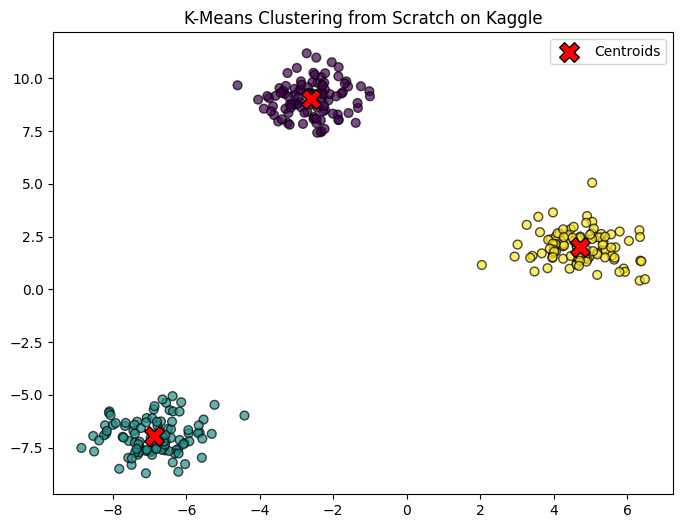

In [3]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

class myKMeans:
    def __init__(self, K=3, max_iters=100):
        self.K = K                  
        self.max_iters = max_iters  
        self.centroids = []             

    def fit(self, X):
        n_samples, n_features = X.shape
        
        random_sample_idxs = np.random.choice(n_samples, self.K, replace=False)
        self.centroids = X[random_sample_idxs]

        for _ in range(self.max_iters):
            clusters = self._create_clusters(X)
            centroids_old = self.centroids.copy()

            self.centroids = self._get_centroids(X, clusters)
            
            if self._is_converged(centroids_old, self.centroids):
                break

    def _create_clusters(self, X):
        clusters = [[] for _ in range(self.K)]
        for idx, sample in enumerate(X):
            centroid_idx = self._closest_centroid(sample, self.centroids)
            clusters[centroid_idx].append(idx)
        return clusters

    def _closest_centroid(self, sample, centroids):
        distances = [np.sqrt(np.sum((sample - point) ** 2)) for point in centroids]
        return np.argmin(distances)

    def _get_centroids(self, X, clusters):
        centroids = np.zeros((self.K, X.shape[1]))
        for cluster_idx, cluster in enumerate(clusters):
            if len(cluster) == 0:
                continue
            cluster_mean = np.mean(X[cluster], axis=0)
            centroids[cluster_idx] = cluster_mean
        return centroids

    def _is_converged(self, centroids_old, centroids_new):
        distances = [np.sqrt(np.sum((centroids_old[i] - centroids_new[i]) ** 2)) for i in range(self.K)]
        return sum(distances) == 0

    def predict(self, X):
        return np.array([self._closest_centroid(sample, self.centroids) for sample in X])

#test
X, _ = datasets.make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=0.8, random_state=42)

kmeans = myKMeans(K=3, max_iters=100)
kmeans.fit(X)

labels = kmeans.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=40, alpha=0.7, edgecolors="k")
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], marker="X", s=200, c="red", edgecolors="black", label="Centroids")
plt.title("K-Means Clustering from Scratch on Kaggle")
plt.legend()
plt.show()